<a href="https://colab.research.google.com/github/JoseAlberto88/Predictive-Analytics-/blob/main/DAMO510_Module_03_in_Class_Activity_StarterCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries that you may pottentially need:

pandas (pd)

NumPy (np)
SciPy (stats)

Matplotlib (plt)

Seaborn (sns)

scikit-learn

statsmodels (sm and smf): Used to fit regression models using statistical formulas and to perform statistical inference.

anova_lm : Performs Analysis of Variance (ANOVA) on the fitted regression model to evaluate the statistical significance of the predictors.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load and inspect your dataset

In [5]:
# This command helps us to see the first 5 observations in the dataset
df = pd.read_csv('/content/drive/MyDrive/Predictive Analytics Course/BostonHousing.csv')
print(df.shape)
df.head()

(506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [6]:
# It's necessarry to see the info() method to see if the dtypes are correctly
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


# Predictive Analytics. Boston Housing Analysis

**Dataset:** BostonHousing.csv (506 rows, 14 columns, no missing values)

**Columns:** crim, zn, indus, chas, nox, rm, age, dis, rad, tax, ptratio, b, lstat, medv

**Target variable:** `medv`. This is the median home value, the standard target for regression tasks on this dataset.

**Status:** Data loaded and verified; assignment instructions pending.

#Find the duplicates

In [7]:
# To find the duplicates we can do the following
# Check for fully duplicate rows
n_duplicates = df.duplicated().sum()
print(f"Number of exact duplicate rows: {n_duplicates}")

if n_duplicates > 0:
    print("\nDuplicate rows:")
    print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))

Number of exact duplicate rows: 0


For the result above, we concludee that there is not **duplicates observations** in the DataSet Boston Housing

#Find missing values

In [8]:
# In a similar way, we can analyze the  missing values
# Check for missing values across all columns
missing_summary = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().sum() / len(df) * 100).round(2)
})

print(missing_summary)
print(f"\nTotal missing values in dataset: {df.isna().sum().sum()}")

         Missing Count  Missing %
crim                 0        0.0
zn                   0        0.0
indus                0        0.0
chas                 0        0.0
nox                  0        0.0
rm                   0        0.0
age                  0        0.0
dis                  0        0.0
rad                  0        0.0
tax                  0        0.0
ptratio              0        0.0
b                    0        0.0
lstat                0        0.0
medv                 0        0.0

Total missing values in dataset: 0


For the table **missing summary** we can conclude that there isn't not missing values for each column.

In [9]:
# Loop through each column: if unique value count > 60, treat as continuous (don't print full value_counts)
# Otherwise, print the full value_counts to inspect for discrete/categorical patterns

for col in df.columns:
    n_unique = df[col].nunique()
    print(f"--- {col} (unique values: {n_unique}) ---")
    if n_unique > 60:
        print("Likely a continuous variable — value_counts not printed (too many distinct values).")
    else:
        print(df[col].value_counts().sort_index())
    print()

--- crim (unique values: 504) ---
Likely a continuous variable — value_counts not printed (too many distinct values).

--- zn (unique values: 26) ---
zn
0.0      372
12.5      10
17.5       1
18.0       1
20.0      21
21.0       4
22.0      10
25.0      10
28.0       3
30.0       6
33.0       4
34.0       3
35.0       3
40.0       7
45.0       6
52.5       3
55.0       3
60.0       4
70.0       3
75.0       3
80.0      15
82.5       2
85.0       2
90.0       5
95.0       4
100.0      1
Name: count, dtype: int64

--- indus (unique values: 76) ---
Likely a continuous variable — value_counts not printed (too many distinct values).

--- chas (unique values: 2) ---
chas
0    471
1     35
Name: count, dtype: int64

--- nox (unique values: 81) ---
Likely a continuous variable — value_counts not printed (too many distinct values).

--- rm (unique values: 446) ---
Likely a continuous variable — value_counts not printed (too many distinct values).

--- age (unique values: 356) ---
Likely a conti

**Summary of what this reveals**

||||
|---|---|---|
|**Column**|**Unique Values**|**Nature**|
|`chas`|2|	**Truly categorical/binary** (0/1 dummy,  borders Charles River or not)|
|`rad`|9|**Discrete/categorical**, but notice the distribution: heavily concentrated at 4, 5, and especially **24** (132 out of 506 rows, ~26%). This is a known quirk of this dataset, 24 is a capped/index value representing "highest accessibility," not a literal count, so it clusters unusually|
|`zn`|26|**Skewed discrete** 372 of 506 rows (73.5%) are exactly 0.0, with the rest spread thinly across many values. This behaves more like a "mostly zero, occasionally something else" variable than a smooth continuous one|
|`ptratio`|26|Below the 60 threshold, so it printed, but looking at the actual values, this is really a **continuous variable with limited precision** (rounded to 1 decimal), not a true category. The spike at 20.2 (140 rows, ~28%) and 14.7 (34 rows) suggests certain school-district ratios were shared across many towns/tracts, not that ptratio is inherently categorical|
|All others (`crim`, `indus`, `nox`, `rm`, `age`, `dis`, `tax`, `b`, `lstat`, `medv`)|66 plus|Correctly flagged continuous|

The 60-unique threshold is a reasonable heuristic, but this data shows its limits: `ptratio` cleared the threshold (46 < 60) and printed a full value_counts, yet it's still fundamentally continuous, just with repeated values because many Boston-area census tracts share the same school district ratio. Similarly, `zn` and `rad` are technically discrete, but their heavy concentration at one dominant value (0 for `zn`, 24 for `rad`) is a data-generation artifact of how these tracts were coded, not evidence of a small number of meaningful categories.

**Only `chas` is genuinely, unambiguously categorical**. it's the sole true binary dummy variable in the dataset. The rest are continuous or discrete-but-effectively-continuous variables that happen to have value repetition due to shared underlying geography (many tracts in the same town share tax rate, ptratio, rad, etc.).

##Plot the histograms of the distribution of each column

Histograms help us understand the distribution of each variable before building a regression model. Specifically, they allow us to:

a)	Identify whether the data is normally distributed, skewed, or multimodal.

b)	Detect potential outliers that may affect the model.

c)	Determine whether a data transformation (e.g., logarithm or square root) might improve the model.

d)	Better understand the characteristics of each predictor before performing feature selection and regression.

Although Multiple Linear Regression does not require the predictors to be normally distributed, understanding their distributions is an important part of exploratory data analysis (EDA).


### Distribution Summary Table

Before visualizing each variable individually, we summarize the shape of every distribution using
skewness. Skewness close to 0 suggests a roughly symmetric/normal-like distribution; positive
skew indicates a right tail (most values low, few high outliers); negative skew indicates a left
tail. This gives an objective basis for interpreting the histograms that follow, rather than
relying on visual impression alone.

In [10]:
# This is teh command to check the distribution type for each continuos variable. Also, we create like a threshold to clearly understand the distution type.

from scipy.stats import skew

summary_rows = []
for col in df.columns:
    n_unique = df[col].nunique()
    col_skew = skew(df[col])

    if abs(col_skew) < 0.5:
        shape = "Approximately symmetric / normal-like"
    elif col_skew >= 0.5 and col_skew < 1:
        shape = "Moderately right-skewed"
    elif col_skew >= 1:
        shape = "Highly right-skewed"
    elif col_skew <= -0.5 and col_skew > -1:
        shape = "Moderately left-skewed"
    else:
        shape = "Highly left-skewed"

    var_type = "Categorical" if col == 'chas' else "Continuous"

    summary_rows.append({
        "Column": col,
        "Type": var_type,
        "Unique Values": n_unique,
        "Skewness": round(col_skew, 2),
        "Distribution Shape": shape
    })

distribution_summary = pd.DataFrame(summary_rows)
distribution_summary

,Column,Type,Unique Values,Skewness,Distribution Shape
0,crim,Continuous,504,5.21,Highly right-skewed
1,zn,Continuous,26,2.22,Highly right-skewed
2,indus,Continuous,76,0.29,Approximately symmetric / normal-like
3,chas,Categorical,2,3.40,Highly right-skewed
4,nox,Continuous,81,0.73,Moderately right-skewed
5,rm,Continuous,446,0.40,Approximately symmetric / normal-like
6,age,Continuous,356,-0.60,Moderately left-skewed
7,dis,Continuous,412,1.01,Highly right-skewed
8,rad,Continuous,9,1.00,Highly right-skewed
9,tax,Continuous,66,0.67,Moderately right-skewed


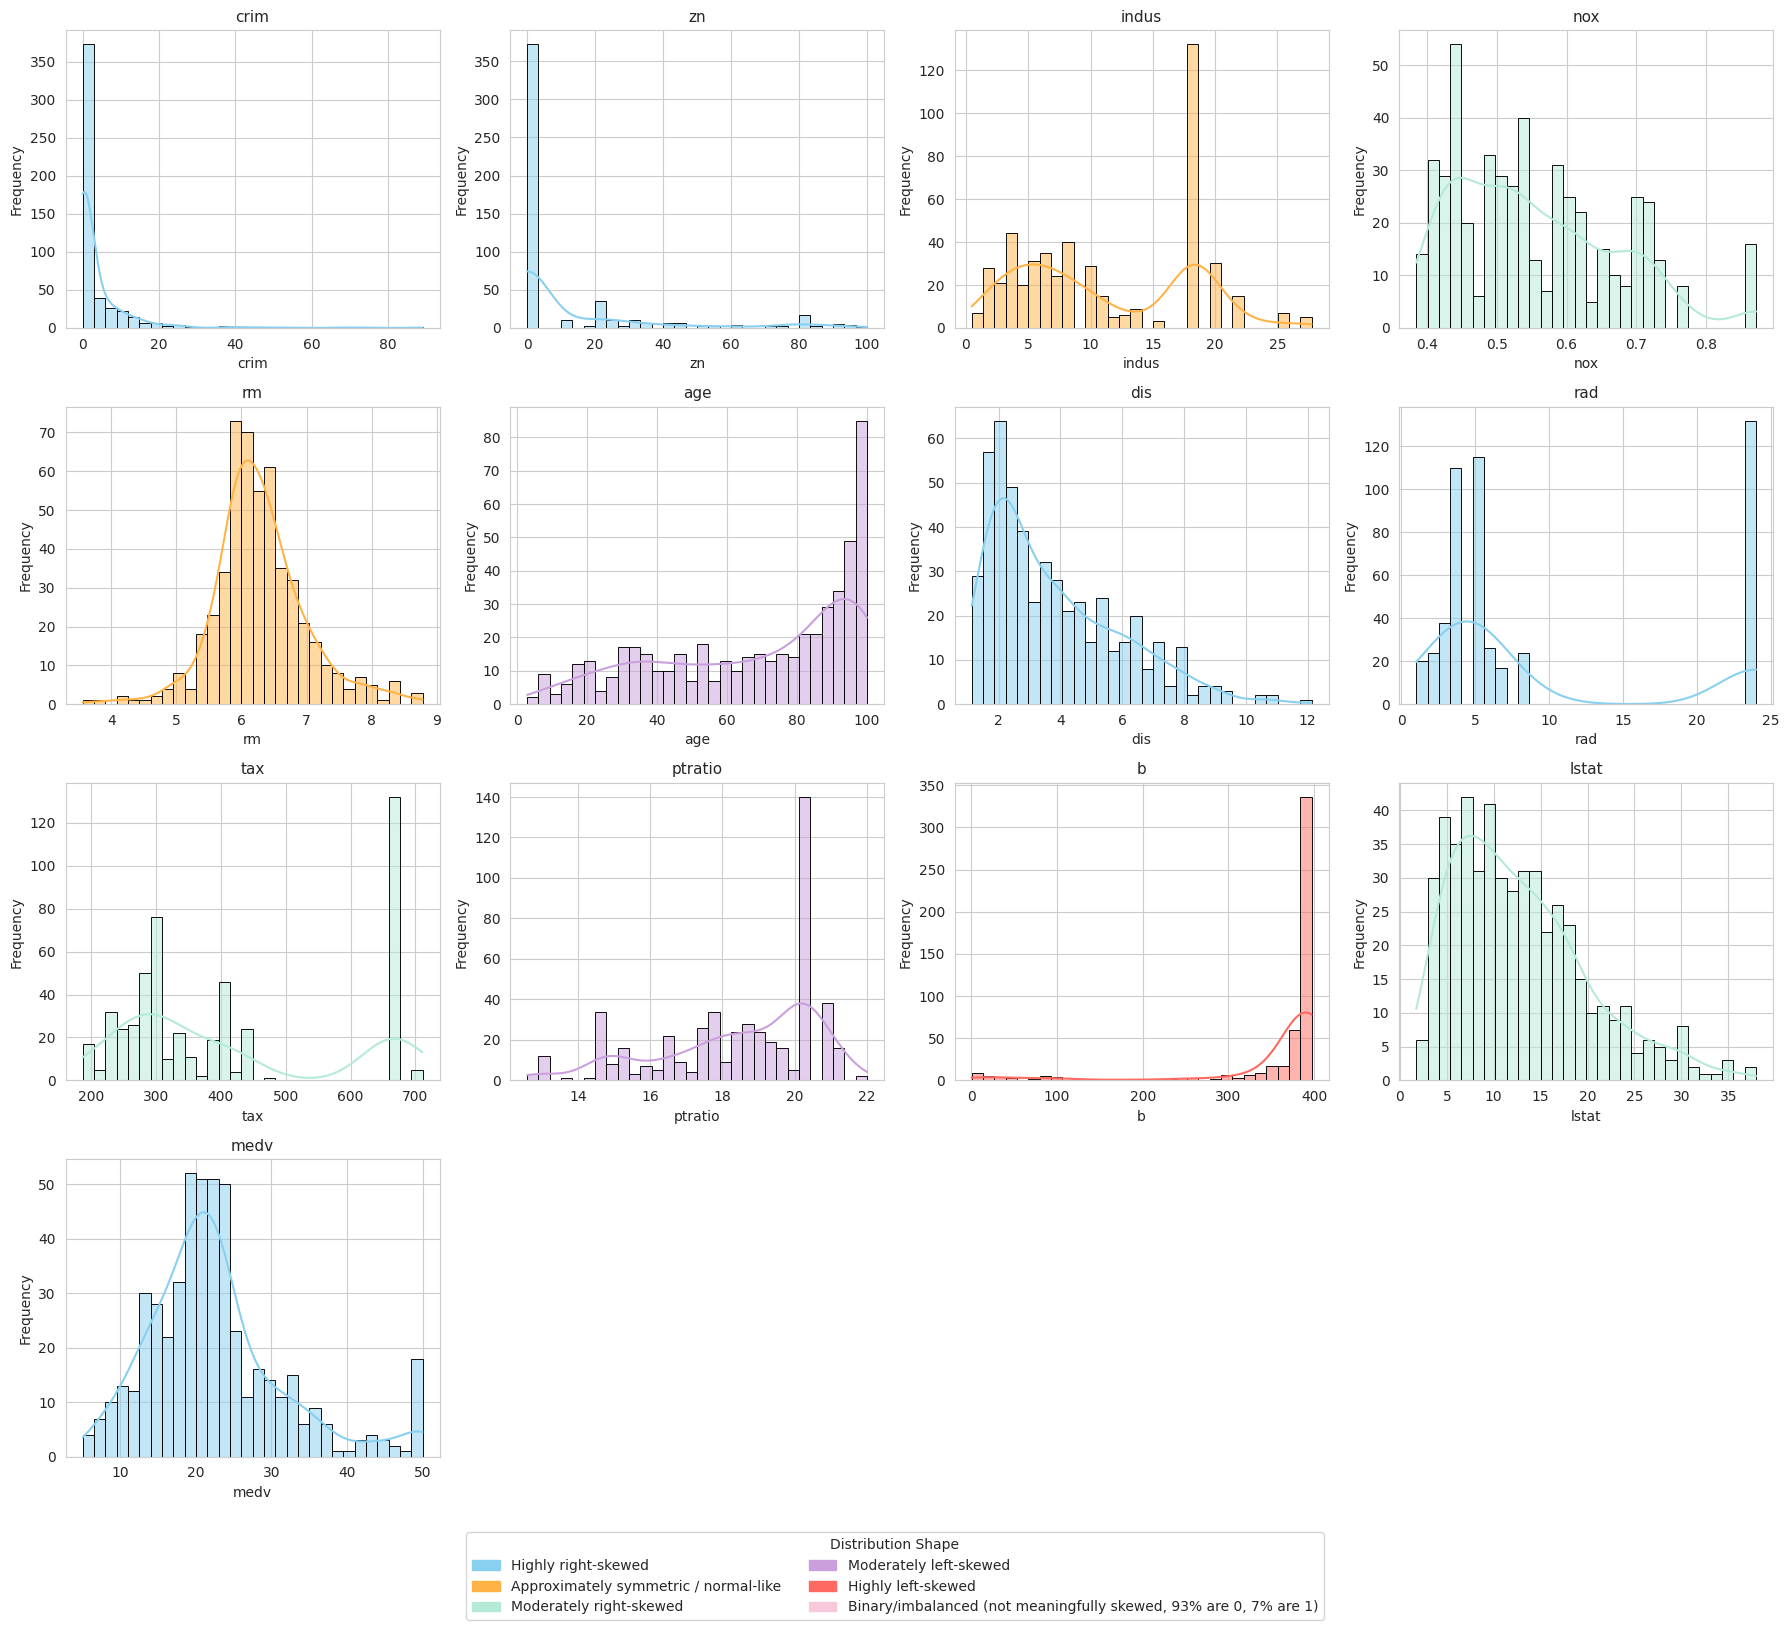

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

shape_color_map = {
    "Highly right-skewed": "#89CFF0",
    "Approximately symmetric / normal-like": "#FFB347",
    "Moderately right-skewed": "#B5EAD7",
    "Moderately left-skewed": "#C9A0DC",
    "Highly left-skewed": "#FF6961",
    "Binary/imbalanced (not meaningfully skewed, 93% are 0, 7% are 1)": "#F8C8DC",
}

sns.set_style("whitegrid")

continuous_cols = [col for col in df.columns if col != 'chas']

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    shape_label = distribution_summary.loc[distribution_summary['Column'] == col, 'Distribution Shape'].values[0]
    color = shape_color_map.get(shape_label, "#D3D3D3")

    sns.histplot(df[col], bins=30, kde=True, color=color, edgecolor='black', ax=axes[i])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(len(continuous_cols), len(axes)):
    axes[j].axis('off')

# Build a single shared legend for the whole figure, based on the color map
legend_patches = [mpatches.Patch(color=color, label=label) for label, color in shape_color_map.items()]
fig.legend(
    handles=legend_patches,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    fontsize=10,
    title="Distribution Shape",
    frameon=True
)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave room at the bottom for the legend
plt.show()

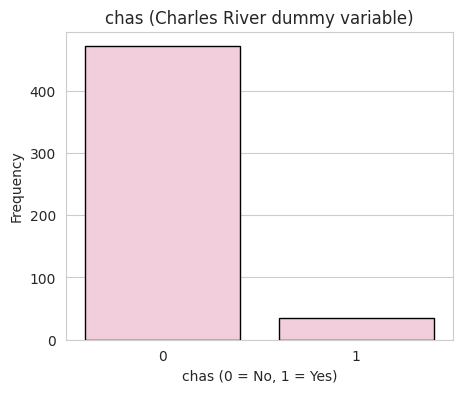

In [16]:
# Define this once, cleanly, instead of repeating the long string as a dictionary key
chas_color = "#F8C8DC"  # pastel pink, same one used in shape_color_map

plt.figure(figsize=(5, 4))
sns.countplot(x=df['chas'], color=chas_color, edgecolor='black')
plt.title("chas (Charles River dummy variable)")
plt.xlabel("chas (0 = No, 1 = Yes)")
plt.ylabel("Frequency")
plt.show()

#Outlier Detection

As we discussed last week, outliers are observations that are unusually far from the rest of the data. Before deciding whether to remove or keep them, we must first detect them.

For each numeric column in the dataset:

Calculate the skewness of the column.

If the distribution is approximately symmetric (e.g., |skewness| < 0.5), use the Z-score method and consider observations with |Z-score| > 3 as potential outliers.

If the distribution is moderately or highly skewed (e.g., |skewness| ≥ 0.5), use the Interquartile Range (IQR) method. Compute Q1, Q3, and IQR, then identify observations outside the interval:

Lower Bound = Q1 - 1.5 * IQR

Upper Bound = Q3 + 1.5 * IQR

Record the indices of the detected outliers for each column and report the number of outliers found.

At this stage, do not remove the outliers. Simply identify them. Their treatment (removal, transformation, capping, or keeping them) should be decided later based on statistical evidence and domain knowledge.

Hint: Use a loop to process every numeric column automatically instead of writing separate code for each variable. This makes your solution reusable for any dataset.

#Remove Outliers from the Dataset

Outliers detected in skewed variables are not removed. Since skewed distributions naturally contain more extreme observations, those outliers should be evaluated more carefully before deciding whether to remove them.

Now that the potential outliers have been identified, create a new cleaned dataset by removing only the observations that were detected as outliers in the approximately normally distributed variables.

Your task is to:

1.	Create a list containing the names of all variables whose absolute skewness is less than 0.5.

2.	Retrieve the outlier indices corresponding to these variables from the dictionary created in the previous step.

3.	Combine all the collected indices into a single list or array. (Hint: a row may appear as an outlier in more than one variable.)

4.	Remove these observations from the original dataset and store the result in a new DataFrame (e.g., df_b). Do not overwrite the original dataset.

5.	Reset the row indices of the new dataset so that they are consecutive.

6.	Display the shape and the first few rows of the cleaned dataset to verify that the operation was successful.



### Outlier Detection

Using the skewness values already computed, each column is routed to the appropriate outlier
detection method: the Z-score method (|Z| > 3) for approximately symmetric distributions
(|skewness| < 0.5), and the IQR method (1.5x beyond Q1/Q3) for moderately or highly skewed
distributions (|skewness| >= 0.5). Outlier indices and counts are recorded per column for later
review. No observations are removed at this stage.

In [18]:
# This command (code) wil help us to create a DataFrame in which we check the skwenss, the method and the number of outliers for each numerical table

from scipy.stats import zscore

outlier_results = {}

for col in df.columns:
    col_skew = skew(df[col])

    if abs(col_skew) < 0.5:
        # Symmetric then Z-score method
        z_scores = zscore(df[col])
        outlier_mask = abs(z_scores) > 3
        method_used = "Z-score"
    else:
        # Skewed then IQR method
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
        method_used = "IQR"

    outlier_indices = df.index[outlier_mask].tolist()

    outlier_results[col] = {
        "Skewness": round(col_skew, 2),
        "Method Used": method_used,
        "Number of Outliers": len(outlier_indices),
        "Outlier Indices": outlier_indices
    }

# Build a summary table (indices omitted here for readability; full lists are in outlier_results)
outlier_summary = pd.DataFrame([
    {
        "Column": col,
        "Skewness": info["Skewness"],
        "Method Used": info["Method Used"],
        "Number of Outliers": info["Number of Outliers"]
    }
    for col, info in outlier_results.items()
])

outlier_summary

,Column,Skewness,Method Used,Number of Outliers
0,crim,5.21,IQR,66
1,zn,2.22,IQR,68
2,indus,0.29,Z-score,0
3,chas,3.40,IQR,35
4,nox,0.73,IQR,0
5,rm,0.40,Z-score,8
6,age,-0.60,IQR,0
7,dis,1.01,IQR,5
8,rad,1.00,IQR,0
9,tax,0.67,IQR,0


In [19]:
# Confirm chas outliers are exactly the minority class
chas_outliers = outlier_results['chas']['Outlier Indices']
print("chas values at flagged indices:", df.loc[chas_outliers, 'chas'].unique())

# Confirm which direction b's outliers fall
b_outliers = outlier_results['b']['Outlier Indices']
print("\nb outlier values (first 10):", sorted(df.loc[b_outliers, 'b'])[:10])
print("Overall b range:", df['b'].min(), "to", df['b'].max())

chas values at flagged indices: [1]

b outlier values (first 10): [0.32, 2.52, 2.6, 3.5, 3.65, 6.68, 7.68, 9.32, 10.48, 16.45]
Overall b range: 0.32 to 396.9


### Outlier Detection: Notes on Interpretation

Two columns in the outlier summary require interpretation beyond the raw count before any
treatment decision is made:

- **`chas`** (35 flagged): Verified that every flagged observation corresponds to `chas = 1`, the
  minority class of this binary dummy variable. This is a methodological artifact of applying a
  continuous-distribution outlier method (IQR) to a binary variable, not a genuine outlier
  finding. `chas` should be excluded from outlier treatment entirely.

- **`b`** (77 flagged): Verified that all flagged values fall at the low end of the variable's
  range (0.32 up to the high teens, against an overall range of 0.32–396.9). `b` is a known
  nonlinear transformation of a tract's Black population proportion, `1000(Bk - 0.63)^2`, which
  produces a ceiling value near a specific proportion and falls off sharply elsewhere. The flagged
  points reflect this structural property of the transformation rather than data entry errors or
  anomalous measurements, and should be treated with that context in mind rather than assumed to
  be candidates for removal.

- **`rad`** (0 flagged despite skew = 1.00): IQR found no outliers even though the column is
  skewed. This is consistent with `rad` being a small set of discrete values (largely 1-8, with a
  large repeated cluster at 24) rather than a smoothly continuous variable,  the skew reflects
  this discrete jump, not a fringe of extreme individual observations.

These three cases illustrate why outlier counts should not be acted on mechanically: the same
statistical test can surface a genuine anomaly, a variable-type mismatch, or a structural artifact
of how a variable was engineered, and distinguishing between them requires understanding what each
variable actually represents.

### Removing Outliers from Approximately Symmetric Variables

This step targets only the variables identified as approximately symmetric (|skewness| < 0.5),
since those were the ones flagged using the Z-score method. Outlier rows from these variables are
combined and removed into a new dataset, `df_b`, leaving the original `df` untouched for
comparison and any alternative treatment decisions on the skewed variables later.

In [20]:
# Step 1: Variables with |skewness| < 0.5
symmetric_vars = [col for col, info in outlier_results.items() if abs(info["Skewness"]) < 0.5]
print("Symmetric variables (|skewness| < 0.5):", symmetric_vars)

Symmetric variables (|skewness| < 0.5): ['indus', 'rm']


In [21]:
# Step 2: Retrieve outlier indices for these variables
symmetric_outlier_indices = {col: outlier_results[col]["Outlier Indices"] for col in symmetric_vars}
for col, indices in symmetric_outlier_indices.items():
    print(f"{col}: {len(indices)} outlier indices -> {indices}")

indus: 0 outlier indices -> []
rm: 8 outlier indices -> [225, 257, 262, 364, 365, 367, 374, 406]


In [22]:
# Step 3: Combine all indices into a single list (a row may appear in more than one variable's list)
combined_indices = []
for indices in symmetric_outlier_indices.values():
    combined_indices.extend(indices)

# Remove duplicates, since the same row could be an outlier in both indus and rm
combined_indices = sorted(set(combined_indices))
print(f"Total unique rows to remove: {len(combined_indices)}")
print(combined_indices)

Total unique rows to remove: 8
[225, 257, 262, 364, 365, 367, 374, 406]


In [23]:
# Step 4: Remove these observations from the original dataset into a NEW DataFrame
df_b = df.drop(index=combined_indices).copy()

print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape (df_b): {df_b.shape}")

Original dataset shape: (506, 14)
Cleaned dataset shape (df_b): (498, 14)


In [24]:
# Step 5: Reset the row indices so they're consecutive
df_b = df_b.reset_index(drop=True)

In [25]:
# Step 6: Verify
print("Shape of df_b:", df_b.shape)
df_b.head()

Shape of df_b: (498, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


### Summary: Outlier Removal (Symmetric Variables Only)

Variables with |skewness| < 0.5 (`indus`, `rm`) were identified as approximately symmetric and
were the ones evaluated using the Z-score method in the prior step. `indus` had 0 flagged
outliers; `rm` had 8. Combining and de-duplicating these indices yielded 8 unique rows to remove.

These rows were dropped from a copy of the original dataset and stored separately as `df_b`
(shape: 498 rows x 14 columns), with the index reset to remain consecutive. The original `df`
(506 rows) was left unmodified, preserving the option to compare model results with and without
this outlier removal, or to apply a different treatment (e.g., IQR-based capping) to the
remaining skewed variables in a later step.

#Transform skewed variables using a logarithmic transformation

Although outliers have already been addressed, some variables may still have moderately or highly skewed distributions. Highly skewed predictors can weaken the performance of a multiple linear regression model by violating the assumption of a linear relationship between the predictors and the target.

Your task is to create a new version of the dataset in which transformed versions of the skewed variables are added.

1) Create a copy of the cleaned dataset from the previous step. Do not modify the existing dataset directly.

2) Identify all variables whose absolute skewness is greater than or equal to 0.5.

3) Loop through these variables and apply a logarithmic transformation using the np.log1p() function. This function computes log⁡(1+x), making it suitable for variables that may contain zero values (we discussed this last week).

4) For each transformed variable, create a new column with an appropriate name (e.g., by adding a "Log_" prefix) instead of replacing the original variable.

5) Display the shape of the new dataset and inspect the first few rows to verify that the transformed columns have been added successfully.


Note: The objective is to reduce the skewness of the predictors while preserving the original variables. This allows you to compare the original and transformed versions later and decide which representation is more appropriate for the regression model.


#Replace the original skewed variables

After creating the logarithmically transformed variables, the dataset now contains both the original skewed variables and their transformed versions. Since both versions represent the same information, keeping both will introduce redundancy and increase the risk of multicollinearity in the regression model.

Your task is to create a new version of the dataset that retains only the transformed variables.

1) Create a copy of the dataset from the previous step.

2) Remove the original skewed variables that were transformed, while keeping their corresponding log-transformed variables.

3) Store the result in a new DataFrame (e.g., df_d) to preserve the previous version of the data.

4) Display the shape and the first few rows of the new dataset to verify that the original skewed columns have been removed successfully.

Note: The goal is to replace the original skewed predictors with their log-transformed counterparts. This simplifies the dataset, reduces redundancy, and prepares the data for feature selection and Multiple Linear Regression.

#Perform correlation analysis and visualize the correlation matrix

Before building a Multiple Linear Regression model, it is important to understand how the variables are related to one another. Correlation analysis helps identify variables that are strongly or weakly related and provides valuable insights for feature selection.

Your task is to:

1) Compute the correlation matrix for all numeric variables in the dataset.

2) Display the correlation matrix to inspect the correlation coefficients between every pair of variables.

3) Create a heatmap to visualize the correlation matrix. Use an appropriate color scale so that strong positive, strong negative, and weak correlations can be easily distinguished.

4) Display the numerical correlation coefficients on the heatmap to make interpretation easier.

5) Add a meaningful title and adjust the figure size so that all variables and correlation values are clearly visible.

Note: The heatmap is an exploratory analysis tool. In the following steps, you will use it to identify:

predictors that have little correlation with the target and may be removed, and predictors that are highly correlated with one another, which may indicate multicollinearity and require further feature selection.

#Identify predictors weakly correlated with the target


Not all predictors contribute meaningfully to predicting the target variable. Variables that have a very weak linear relationship with the target often provide little predictive value and may unnecessarily increase the complexity of the model.

Your task is to:

1) Create a copy of the dataset from the previous step to preserve the original version.

2) Write a reusable function that accepts a DataFrame, the name of the target variable, and a correlation threshold as inputs.

3) Within the function, compute the correlation matrix for the dataset.

4) Extract the correlation coefficient between each predictor and the target variable, excluding the target's correlation with itself.

5) Identify all predictors whose absolute correlation with the target is less than 0.30. Use the absolute value because both positive and negative correlations may indicate useful relationships.

6) Display the names of these predictors along with their correlation coefficients in a clear and readable format, and report how many predictors satisfy the condition.

7) Return the names of the weakly correlated predictors as a Python list. This list will be used in the next step to remove these variables from the dataset.

Note: The threshold of |correlation| < 0.30 is a commonly used rule of thumb for identifying predictors that have a weak linear relationship with the target. Removing such predictors can simplify the model, reduce noise, and improve interpretability without significantly affecting predictive performance.

#Identify predictors that are highly correlated with one another

After removing predictors that are weakly related to the target, the next step is to identify multicollinearity among the remaining predictors. Multicollinearity occurs when two or more predictors contain very similar information, which can make the regression coefficients unstable and difficult to interpret.

Your task is to:

1) Create a new version of the dataset by removing the predictors identified in the previous step as being weakly correlated with the target.

2) Write a reusable function that accepts a DataFrame, the name of the target variable, and a correlation threshold as inputs.

3) Compute the correlation matrix for the dataset.

4) Exclude the target variable from the analysis so that only the relationships among the predictors are considered.

5) Identify all pairs of predictors whose absolute correlation coefficient is greater than 0.70.

6) Ensure that each predictor pair appears only once in the output (e.g., report A-B but not B-A).

7) Display the highly correlated predictor pairs together with their absolute correlation coefficients, sorted from the strongest to the weakest correlation.

Note: A correlation coefficient greater than 0.70 is a commonly used rule of thumb for identifying potential multicollinearity. At this stage, do not remove any variables yet. Simply identify the highly correlated predictor pairs. In the next step, you will decide which predictor from each pair should be retained based on its relationship with the target variable, domain knowledge, and overall model quality.

#Visualize strong correlations among predictors

Although the previous step identified highly correlated predictor pairs in a table, a heatmap provides a more intuitive way to visualize these relationships. By displaying only the strongest correlations, the heatmap makes it easier to identify groups of predictors that may cause multicollinearity.

Your task is to:

1) Create a list containing only the predictor variables, excluding the target variable.

2) Compute the correlation matrix for these predictors.

3) Create a mask that retains only predictor pairs whose absolute correlation coefficient is greater than 0.70.

4) Apply the mask to the correlation matrix so that weaker correlations are hidden from the visualization.

5) Plot the resulting matrix as a heatmap, displaying the correlation coefficients on the figure.

6) Add an appropriate title and adjust the figure size so that the heatmap is easy to read.

Note: The purpose of this visualization is to highlight only the predictor pairs that may introduce multicollinearity. The heatmap should make it easier to determine which variables require further investigation before building the Multiple Linear Regression model.


#Remove collinear predictors and verify the results

After identifying the highly correlated predictor pairs, the next step is to reduce multicollinearity by removing one predictor from each highly correlated pair. The goal is to retain the most informative predictors while eliminating redundant ones.

Your task is to:

1) Review the table and heatmap produced in the previous step and identify the predictor pairs whose absolute correlation coefficient exceeds 0.70.

2) For each highly correlated pair, decide which predictor to keep and which one to remove. Justify your decisions based on:

the predictor's correlation with the target variable,

domain knowledge,

interpretability,

measurement reliability, and

redundancy with other predictors.

3) Store the names of the selected predictors to be removed in a Python list.

4) Create a new version of the dataset by removing the selected predictors. Do not overwrite the previous dataset.

5) Display the shape and the first few rows of the new dataset to verify that the selected columns have been removed successfully.

6) Recompute the predictor-to-predictor correlation matrix using the updated dataset.

7) Create a heatmap that displays only the remaining strong correlations (e.g., |correlation| > 0.70).

8) Exclude the target variable from this visualization and hide self-correlations if desired.

9) Compare the new heatmap with the previous one to verify that the major multicollinearity issues have been resolved.

Note: The objective is not to eliminate every correlation between predictors. Instead, the goal is to remove redundant predictors so that the remaining variables provide unique information to the regression model. If the heatmap still shows strong predictor-to-predictor correlations after this step, revisit your feature selection decisions before proceeding to build the Multiple Linear Regression model.

# Build and evaluate a multiple linear regression model

After selecting the final set of predictors, you are ready to build a Multiple Linear Regression (MLR) model to predict the target variable. The objective is to train the model using part of the dataset and then evaluate how well it predicts unseen data.

Your task is to:

1) Separate the dataset into:

Predictors (X): all remaining predictor variables.

Target (y): the target variable.

Split the dataset into training and testing sets. Use 80% of the data for training the model and 20% for testing its predictive performance. Set a fixed random state so that your results are reproducible.

2) Create and train a Multiple Linear Regression model using the training data.

3) Use the trained model to predict the target values for the testing dataset.

4) Evaluate the model by computing:

Coefficient of Determination (R^2): measures the proportion of the variation in the target variable explained by the model. Larger values (closer to 1) indicate better model performance.

Root Mean Square Error (RMSE): measures the average prediction error in the same units as the target variable. Smaller values indicate better predictive accuracy.

Display the R^2 and RMSE values with appropriate formatting.

Note: The testing dataset should be used only for evaluating the model after it has been trained. It must not be used during model fitting. Using separate training and testing datasets provides a more realistic estimate of how well the model is expected to perform on new, unseen data.

#Perform ANOVA to evaluate the significance of the predictors

After building a Multiple Linear Regression (MLR) model, it is important to determine which predictors actually contribute to explaining the target variable. While the regression model provides predictions, it does not automatically tell us whether every predictor is useful. Some predictors may contribute very little once the effects of the other predictors are taken into account.

To answer this question, we perform an Analysis of Variance (ANOVA) on the fitted regression model.

Your task is to:

1) Create a new DataFrame that contains both the predictor variables and the target variable. This dataset will be used to fit the regression model using the formula interface provided by the statsmodels library.

2) Construct the regression formula programmatically by combining the target variable with all the remaining predictor variables. Avoid manually typing the predictor names so that your code can be reused for different datasets.

3) Fit a Multiple Linear Regression model using the formula-based syntax.

4) Perform a Type II ANOVA on the fitted model. Type II ANOVA evaluates the contribution of each predictor while accounting for the effects of all the other predictors already included in the model.

5) Display the resulting ANOVA table.

The ANOVA table contains several columns, but the two most important ones are:

a) F-statistic: Measures how much a predictor helps explain the variation in the target variable relative to the unexplained variation (random error). In general, larger F-statistics indicate that the predictor contributes more information to the model.

b) p-value (PR(>F)): Indicates whether the observed contribution of a predictor is statistically significant. A small p-value suggests that the predictor is unlikely to appear important simply due to random chance.

When interpreting the results, use the following guideline:

1) p-value < 0.05: The predictor is considered statistically significant and contributes meaningfully to the regression model.

2) p-value ≥ 0.05: The predictor is not statistically significant, meaning that after accounting for the other predictors, it provides little additional explanatory power.

Remember that statistical significance should not be interpreted in isolation. A predictor with a relatively large p-value may still be retained if there are strong theoretical, practical, or domain-specific reasons to keep it.

Note: ANOVA is a model interpretation tool rather than a model evaluation metric.

Unlike R^2 and RMSE, which measure how well the model predicts the target variable, `ANOVA helps determine which predictors are responsible for those predictions`. It is commonly used during feature selection and model refinement to identify predictors that may be removed, resulting in a simpler and more interpretable regression model without substantially reducing predictive performance.

# Analyze the residuals and verify the regression assumptions

Building a Multiple Linear Regression model is only part of the analysis. Before trusting the model's predictions and statistical results, you should examine the residuals to determine whether the model satisfies the assumptions of linear regression.

A residual is the difference between the actual value and the predicted value for an observation.

Residual = Actual Value - Predicted Value

Residual analysis helps identify problems such as non-linearity, unequal error variance, outliers, or violations of the normality assumption. These issues can reduce the reliability of the regression model and its statistical inferences.

Your task is to:

1) Compute the residuals by subtracting the predicted values from the actual target values in the testing dataset.

2) Create a Residuals vs. Predicted Values scatter plot.

3) Plot the predicted values on the horizontal axis.

4) Plot the residuals on the vertical axis.

5) Add a horizontal reference line at 0 to make it easier to evaluate the distribution of the residuals.

6) Examine whether the residuals are randomly scattered around zero.

7) Look for patterns such as curves, clusters, or funnel-shaped distributions, which may indicate violations of the linearity or constant variance assumptions.

8) Create a histogram of the residuals.

9) Display the distribution of the residuals.

10) Include a kernel density estimate (KDE) curve to better visualize the overall shape of the distribution.

11) Assess whether the residuals appear approximately bell-shaped and centered around zero.

12) Create a Q-Q (Quantile-Quantile) plot of the residuals.

13) Compare the distribution of the residuals with a theoretical normal distribution.

14) Examine whether the points closely follow the reference line.
Large departures from the line, especially in the tails, may indicate that the residuals are not normally distributed.

When interpreting your results, consider the following guidelines:

a) Residuals vs. Predicted Values

b) A well-fitting regression model should produce a scatter plot in which:

- The residuals are randomly scattered around the horizontal line at zero.
- There are no obvious trends, curves, or systematic patterns.
- The spread of the residuals is relatively constant across the range of predicted values.

-- Potential problems include:

- Curved patterns: suggest that the relationship between the predictors and the target may not be purely linear.

- Funnel-shaped patterns: indicate that the variance of the residuals changes across the range of predictions (heteroscedasticity).

- Extreme residuals: may indicate outliers or influential observations.

## Histogram of Residuals

The histogram should show residuals that are:

-- Approximately symmetric.
-- Centered near zero.
-- Roughly bell-shaped.

Small deviations from normality are common and are usually acceptable, particularly when the sample size is reasonably large.

## Q-Q Plot

-- The Q-Q plot provides a more reliable assessment of normality than the histogram.

-- If most points lie close to the diagonal reference line, the residuals are approximately normally distributed.

-- Moderate deviations at the extreme ends of the plot are generally acceptable.

-- Large or systematic deviations from the line suggest that the normality assumption may not hold.

Note: In Multiple Linear Regression, it is the residuals not the predictor variables or the target variable that should be approximately normally distributed. This assumption is important because it supports the validity of statistical inference, including confidence intervals, hypothesis tests, and the ANOVA results obtained in the previous step. Even if the residuals are not perfectly normal, minor departures are often acceptable in practice, particularly when working with larger datasets.

# Examine the residuals for each predictor variable

In this step, you will examine how the residuals behave with respect to each individual predictor. These plots help determine whether the assumption of a linear relationship between each predictor and the target variable is reasonable.

Your task is to:

1) Compute the residuals by subtracting the predicted values from the actual target values in the testing dataset.

2) Create a loop that generates a Residuals vs. Predictor scatter plot for every predictor variable.

3) For each plot:
- Place the predictor values on the horizontal axis.
- Place the residuals on the vertical axis.
- Add a horizontal reference line at Residual = 0.
- Include appropriate axis labels and a descriptive title.
- Display each plot individually and examine the pattern of the residuals.

When interpreting the plots, look for the following:

-- Good result: The residuals are randomly scattered around zero with no obvious pattern and a relatively constant spread.

-- Curved pattern: May indicate that the relationship between the predictor and the target is not linear.

-- Funnel-shaped pattern: Suggests that the variance of the residuals changes across the predictor values (heteroscedasticity).

-- Extreme points: May indicate outliers or influential observations.

Note: These plots evaluate the relationship between the residuals and each predictor individually. If most plots show random scatter around zero without systematic patterns, the linearity assumption of Multiple Linear Regression is reasonably satisfied.

# Final Discussion

Based on your analysis:

1) Is the model a good predictor?

2) Which predictors are statistically significant?

3) Are the regression assumptions reasonably satisfied?

4) What improvements could be made?